# Milestone 3: EDA, Planning, and Setting Goals

[Due 4/18: Instructions](https://edstem.org/us/courses/74185/lessons/130679/slides/736236)

**Data Description**

[] -  Provide any missing information from Milestone 2 based on the feedback you received from your grader. 

Elaine's comments

[X] - (TED COMMENT: fixed and added note below) You say "we want to go back two years and pull the state record for the 1st and 15th of each month". From Ted's data acquisition notebook, the data collection begins in March 2023 and ends in March 2024, covering a total of 13 months. I am wondering why this time interval was chosen and the choice of the 1st and 15th.
Why nothing up to today's date?

[X] - (TED COMMENT:added clarification + new table below) If I understand correctly, you’re tracking 31,313 unique objects that include active payloads, analyst objects, and debris. But the space-track website says there should be 47,800 of these? where is all the others? 

[] - (TED COMMENT: not sure what to change here?) Across time, those 31,313 objects have 1,034,009 recorded states which averages to about 33 states per object.


[X] - (TED COMMENT: added table; lmk if other acronyms are missing) Please define acronyms for lay-people. I don't think you explain was RCS is. Of course, it takes a second for me to look up. Also, L/M/GEO and HEO.


[X] - (TED COMMENT: added clarifying note in Data Summary) Are "IS_CURRENT" and "Decayed" opposite classifications? "Decayed" here just means that it has fallen out of it's orbit even slightly and will eventually burn up?

[X] - (MAX COMMENT: not sure if this is what Elaine meant, but I added "Figure X" in the suptitle of each plot.) For each of the plots that you have displayed, please add a "Figure x: blah blah" description. 

[] - There were several plots where I wasn't really seeing the point of displaying it. 

[] - Also, your "Numeric Variables for Observations without RCS" plots have a x axis tick labels that are overlapping. 

[X] - (TED COMMENT: added comment below) Wouldn't "Rocket Body" just be considered "Debris"? 

[] - (MAX COMMENT: sorry, this was my fault.) Plots "# Plot distribution of categories for all categorical variables" have no titles. Tisk tisk. 

[] - Please rotate x-axis labels instead of having them be straight up vertical.

[X] - (MAX COMMENT: shown below) It would be good to display `df_scaled` so that I can see the new rows. 

[] - (TED COMMENT: I think NNs will perform better than RFs; not sure how to address this point/whether or not to. MAX COMMENT: Maybe using LSTM/Transformer can capture memory/temporal context which could be important?) You have plenty of data for a modeling task and it is now in a nice, clean package. But if your goal is to use TYPE and STATE as response variables, I am wondering what model from this course you will use? Some of you were in CS1090a and it seems like this could easily be done with decisions trees or a random forest. 


**Summary of the Data**

[X] - Provide the shape of the data, data types, and descriptive statistics such as mean, max, and dtypes. 

[X] - Additionally, provide a summary of the features of the data, including histograms, correlation plots, and clustering plots as appropriate. 

**Data Analysis**

[] - Identify patterns, trends, and outliers in the data. 

[] - Additionally, explore the relationships between variables and identify any potential confounding variables that may impact the analysis.

**Meaningful Insights** 

[] - Based on your analysis of the data, provide meaningful insights. Meaningful insights are those that connect back to your problem and are relevant to your specific context. Any insights should be well-supported by the data, provide actionable recommendations, and have a brief justification for why or how it’s important to the project. 

**Clean and Labeled Visualizations**

[] - Visualizations are important components of EDA and should be clean, labeled, and well-presented. 

[] - You need to ensure that your visualizations are easy to understand and can be included in their final presentation slides or report. 

[] - Anyone that reads your EDA should be able to understand what is depicted in the plots just by looking at them. Viz's that are not labeled correct will result in a loss of pts. 

**Summary of findings** 

[] - Summarize your findings in a clear and concise manner. This can be achieved through the use of visualizations and captions that highlight the most important insights gained through the analysis.

**(Revised) Project Question**

[] - Based on the insights gained through EDA, you should develop a clear project/research question that will guide your analysis. This question should be well-defined, specific to the problem at hand, and an improvement from the initial project proposal.

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# utilities
import utils.preprocessing as pp
import utils.visualization as viz

## Data Description

Our final data frame consists of data from:

1. Historical State information - collected from spacetrack on the 1st and 15th of each moth ranging from 03/15/2023 to 03/15/2025 (*)

2. Satellite catalog (satcat) information - descriptive information about a satellite.

3. Calculated additional values - semi-major axis, apogee, perigee, and orbital regime need to be calculated using state information.

(*) Note: Previously our [DataAcquisition.ipynb](https://github.com/tedinspace/space-object-identification/blob/main/src/DataAcquisition.ipynb) notebook had the date range from '2023-03-15' to '2024-03-15', which was mentioned in our M2 comments. This is because the spacetrack api has a limited number of calls you can make per hour, so Ted broke up the calls into two runs (one per year). Realistically, you should be able to run this number of calls without a problem, but Space-Track had already issued a warning to Ted while he was making test calls. They are known to delete accounts that break too many api rules; Ted should know.

In [2]:
# load our data
satCat_current = pd.DataFrame(pp.loadUnprocessedSatCat_current("../data/satcat.zip")).set_index("NORAD_CAT_ID")
satCat_decayed = pd.DataFrame(pp.loadUnprocessedSatCat_decayed("../data/satcat.zip")).set_index("NORAD_CAT_ID")
snapshot_states = pp.loadSeveralYearsOfUnprocessedStates(["../data/snapshots_2023.zip","../data/snapshots_2024_p1.zip","../data/snapshots_2024_p2.zip","../data/snapshots_2025.zip"])
aggregatedData, uncataloged_states, nDuplicatesFound = pp.deduplicateAndMergeDataSources(snapshot_states, satCat_current, satCat_decayed)

# display shape of data
df = pd.DataFrame(aggregatedData)
df.shape

(1034009, 20)

<table>
    <tr>
        <th>Source</th> <th>Payload</th> <th>Debris + Rocket Bodies</th> <th>Analyst Objects</th> <th>TOTAL</th> 
    </tr>
    <tr>
        <td>Space-Track's login page</td> <td>11,400</td> <td>18,800</td> <td>17,500</td> <td>47,700</td> 
    </tr>
    <tr>
        <td>Our Space-Track snapshots</td> <td>15,145</td> <td>15,350 (12,999 + 2,351)</td> <td>818</td> <td>31,313</td> 
    </tr>
    <tr>
        <td>Our Space-Track snapshots (decayed objects removed)</td> <td>13,418</td> <td>13,614 (11,440 + 2,174)</td> <td>584</td> <td>27,616</td>
    </tr>
    <tr>
        <td>CelesTrak.org</td> <td>14,610 **</td> <td>15,611</td> <td>n/a</td> <td>33,158</td> 
    </tr>
</table>

** [Celestrak](https://celestrak.org/satcat/boxscore.php) has the active payload count at 11,614, which is closer but not identical to Space-Track. 


**Why Don't These Numbers Match?**

1. [Not all Space-Track accounts are the same.](https://www.space-track.org/myprofile#permissions) Some accounts have access to states that are not public; most of these fall under analyst objects, but could also include other object types.

2. [CelesTrak](https://celestrak.org/satcat/sources.php) compiles data from different countries--not only relying on Space-Track

3. When Space-Track says "payloads" on their landing page, they mean "active payloads," i.e., satellites that are still being flown/operated. Unfortunately, with this level of access, Space-Track doesn't indicate which objects are active and which are not. [The field "CURRENT" is always set to "Y" and never "N"](https://www.space-track.org/basicspacedata/query/class/satcat/CURRENT/N/emptyresult/show). Ideally, we would have the type categories of **PAYLOAD_ACTIVE** and **PAYLOAD_INACTIVE**, but that information is not readily available on unclassified systems. Inactive payloads are typically placed in [graveyard orbits](https://spaceplace.nasa.gov/spacecraft-graveyard/en/), which should make them distinguishable from debris and rocket bodies in our model.


**Aren't rocket bodies just debris?**

Technically, yes, but they are a specific type of debris. They are typically large and will likely respond to perturbations differently than small space-trash debris.


In [3]:
# create dataframe of objects
df_no_dup = df.drop_duplicates(subset="NUMBER", keep="first")

# display information on unique objects
print(f"{df_no_dup.shape[0]} unique objects")
print(df_no_dup['TYPE'].value_counts())
print('')

# display information on current unique objects
df_no_dup = df_no_dup[df_no_dup['IS_CURRENT']==1]
print(f"{df_no_dup.shape[0]} unique objects - not decayed")
print(df_no_dup['TYPE'].value_counts())

31313 unique objects
TYPE
PAYLOAD        15145
DEBRIS         12999
ROCKET BODY     2351
UNKNOWN          818
Name: count, dtype: int64

27616 unique objects - not decayed
TYPE
PAYLOAD        13418
DEBRIS         11440
ROCKET BODY     2174
UNKNOWN          584
Name: count, dtype: int64


In [4]:
# removing analyst objects 
df = df[df['TYPE'] != 'UNKNOWN']
df.reset_index(drop=True, inplace=True)
df.shape

(1011052, 20)

In [5]:
# defining the different variables in our dataset
response = 'TYPE'
X_exclude = ['NUMBER', 'NAME','RCS', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2']
X_numerical = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_ANOM', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER']
X_numerical2 = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION', 'SMA_KM','APOGEE_KM', 'PERIGEE_KM', 'MEAN_MOTION_1ST_DER'] # no mean anom
column_names_map = viz.pretty_column_names()

In [6]:
# scale data for better performance with neural nets
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[X_numerical]), columns=X_numerical)
df_scaled.reset_index(drop=True, inplace=True)
df_response = df[[response]]
df_response.reset_index(drop=True, inplace=True)
df_exc = df[X_exclude]
df_exc.reset_index(drop=True, inplace=True)
df_scaled = pd.concat([df_response, df_scaled, df_exc], axis=1)

# display the data
df_scaled.head(2)

,TYPE,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,NUMBER,NAME,RCS,IS_CURRENT,REGIME,EPOCH,COUNTRY,LINE1,LINE2
0,PAYLOAD,-1.196979,-1.313405,0.685616,1.243249,-1.344251,-0.153392,-0.274948,-0.208660,-0.323569,-0.032034,11,VANGUARD 2,MEDIUM,1,LEO,23227.529469,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,ROCKET BODY,-1.196343,0.862265,0.819142,-1.424497,1.452507,-0.246231,-0.255350,-0.176047,-0.323377,-0.031479,12,VANGUARD R/B,MEDIUM,1,LEO,23227.463430,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


## Summary of the Data


#### Acronyms to Watch Out For

<table>
  <tr>
    <th>Acronyms</th>  
    <th>Meaning</th>  
    <th>Details</th> 
</tr>
<tr>
    <td>TLE</td>  <td>Two-Line Element</td>  <td>How orbits are typically published; two 69 character length strings </td> 
</tr>
<tr>
    <td>LEO</td>  
    <td>Low Earth Orbit</td>  
    <td>Falls around 2,000 km above the Earth's surface.</td> 
</tr>
<tr>
    <td>MEO</td>  
    <td>Medium Earth Orbit</td>  
    <td>Falls between 2,000 and 35,786 km above the Earth's surface.</td> 
</tr>
<tr>
    <td>HEO</td>  
    <td>Highly Eccentric Orbit</td>  
    <td>These have high eccentricity, meaning they are elliptical in shape and have large disparities between their apogee and perigee.</td> 
</tr>
<tr>
    <td>GEO</td>  
    <td>Geostationary Orbit or Geosynchronous Orbit</td>  
    <td>These are around 35,786 km from the Earth's surface. "Geostationary" and "Geosynchronous" are used interchangeably, but strictly speaking, Geostationary orbits have low inclination and match the Earth's rotation almost exactly. Geosynchronous orbits expand the definition to include satellites with higher inclinations and less precise periods.</td> 
</tr>
    <tr>
    <td>RCS</td>  <td>Radar Cross Section</td>  <td>Formally it refers to the object's RADAR signature (how much energy an object reflects back at the RADAR), but informally refers to the size of the object. If the object is large (and not stealth), more energy will be reflected back at the RADAR</td> 
</tr>
<tr>
    <td>RAAN</td>  <td>The Right Ascension of the Ascending Node </td>  <td>One of the orbital elements;  longitude of the point where the spacecraft crosses the equatorial plane </td> 
</tr>
<tr>
    <td>SMA</td>  <td>semi-major axis</td>  <td>One of the orbital elements;  distance from the center of an orbit to the longer end of the orbit</td> 
</tr>
</table>

#### Description of Features

<table>
    <tr>
        <th>Include in Model</th> <th>Feature</th> <th>Data Type</th> <th>Units</th> <th>Description</th>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NAME</td> <td>String</td> <td>-</td> <td>Name of satellite</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>NUMBER</td> <td>String</td> <td>-</td> <td>NORAD assigned RSO number</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes (Response)</td> <td>TYPE</td> <td>String/Enum</td> <td>-</td> <td>Type of object: payload, debris, rocket body</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>RCS</td> <td>String/Enum</td> <td>-</td> <td>Radar Cross Section - encoding of object size</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>IS_CURRENT</td> <td>Boolean</td> <td>-</td> <td>Whether or not the object has decayed since we started collecting catalog data. Note: The satellite catalog has a field called "CURRENT," which is not the same as this. We created this variable to track how many objects burned up in orbit (decayed) since our catalog start (3-15-2023). It is only accurate up until we stopped collecting data (3-15-2025).</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>REGIME</td> <td>String/Enum</td> <td>-</td> <td>Orbital regime of data</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>EPOCH</td> <td>Float</td> <td>Year/Day of Year/Fraction</td> <td>Validity time for state</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>INCL</td> <td>Float</td> <td>Degree</td> <td>Orbit inclination</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>RAAN</td> <td>Float</td> <td>Degree</td> <td>Right Ascension of the Ascending Node - longitude of the point where the spacecraft crosses the equatorial plane</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ECC</td> <td>Float</td> <td>[0,1]</td> <td>Eccentricity - measure of how circular or elliptical an orbit is</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>ARG_PER</td> <td>Float</td> <td>Degree</td> <td>Argument of perigee - rotation/orientation of orbit</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>MEAN_ANOM</td> <td>Float</td> <td>Degree</td> <td>Mean anomaly - where the object is at epoch in orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION</td> <td>Float</td> <td>Rev/Day</td> <td>Revolutions per day given orbit</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>SMA_KM</td> <td>Float</td> <td>KM</td> <td>Semi-major axis - the distance from the center of an ellipse to the longer end of the ellipse</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>APOGEE_KM</td> <td>Float</td> <td>KM</td> <td>Furthest orbit gets from Earth</td>
    </tr>
    <tr>
        <td style="background-color: orange;">Maybe</td> <td>PERIGEE_KM</td> <td>Float</td> <td>KM</td> <td>Closest orbit gets from Earth</td>
    </tr>
    <tr>
        <td style="background-color: green;">Yes</td> <td>MEAN_MOTION_1ST_DER</td> <td>Float</td> <td>Rev/Day<sup>2</sup></td> <td>Ballistic coefficient measure</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>COUNTRY</td> <td>String</td> <td>-</td> <td>Country code pulled from Satellite Catalog</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE1</td> <td>String</td> <td>-</td> <td>First line of TLE</td>
    </tr>
    <tr>
        <td style="background-color: red;">No</td> <td>LINE2</td> <td>String</td> <td>-</td> <td>Second line of TLE</td>
    </tr>
</table>


In [7]:
# preview of unscaled data
df.head(2)

,NUMBER,NAME,TYPE,RCS,IS_CURRENT,REGIME,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER,COUNTRY,LINE1,LINE2
0,11,VANGUARD 2,PAYLOAD,MEDIUM,1,LEO,23227.529469,32.8786,39.4077,0.146176,291.2012,53.8788,11.872714,8116.494528,2924.83529,551.953765,0.000004,US,1 11U 59001A 23227.52946902 .00000437 0...,2 11 32.8786 39.4077 1461765 291.2012 53...
1,12,VANGUARD R/B,ROCKET BODY,MEDIUM,1,LEO,23227.463430,32.8971,270.9551,0.165991,26.7664,340.9673,11.457434,8311.452812,3312.97502,553.730604,0.000006,US,1 12U 59001B 23227.46343039 .00000595 0...,2 12 32.8971 270.9551 1659905 26.7664 340...


In [8]:
# describe unscaled data
df.describe()

,IS_CURRENT,EPOCH,INCL,RAAN,ECC,ARG_PER,MEAN_ANOM,MEAN_MOTION,SMA_KM,APOGEE_KM,PERIGEE_KM,MEAN_MOTION_1ST_DER
count,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06,1.011052e+06
mean,9.295101e-01,2.394033e+04,6.769199e+01,1.791879e+02,4.443714e-02,1.679667e+02,1.918668e+02,1.255885e+01,1.085167e+04,5.408207e+03,3.538930e+03,9.569788e-05
std,2.559710e-01,6.208343e+02,2.908439e+01,1.064258e+02,1.483912e-01,9.912299e+01,1.026505e+02,4.473118e+00,9.947967e+03,1.190155e+04,9.231346e+03,2.851011e-03
min,0.000000e+00,2.307400e+04,3.000000e-04,2.000000e-04,1.000000e-06,1.800000e-03,1.000000e-04,3.183586e-02,6.486968e+03,1.225964e+02,7.893477e+01,-5.779533e-02
25%,1.000000e+00,2.327437e+04,5.305310e+01,8.530457e+01,1.819000e-04,8.704080e+01,9.466045e+01,1.313470e+01,6.925375e+03,5.484600e+02,5.391871e+02,4.300000e-07
50%,1.000000e+00,2.409250e+04,7.145945e+01,1.761789e+02,1.527800e-03,1.480048e+02,2.139979e+02,1.433189e+01,7.159229e+03,8.266858e+02,6.785810e+02,1.052000e-05
75%,1.000000e+00,2.427532e+04,9.759410e+01,2.738752e+02,8.646425e-03,2.630657e+02,2.744034e+02,1.506391e+01,7.587902e+03,1.336963e+03,9.559758e+02,6.325000e-05
max,1.000000e+00,2.507500e+04,1.527004e+02,3.600000e+02,9.650900e-01,3.599992e+02,3.600000e+02,1.661652e+01,4.205240e+05,5.395501e+05,2.887417e+05,1.000000e+00


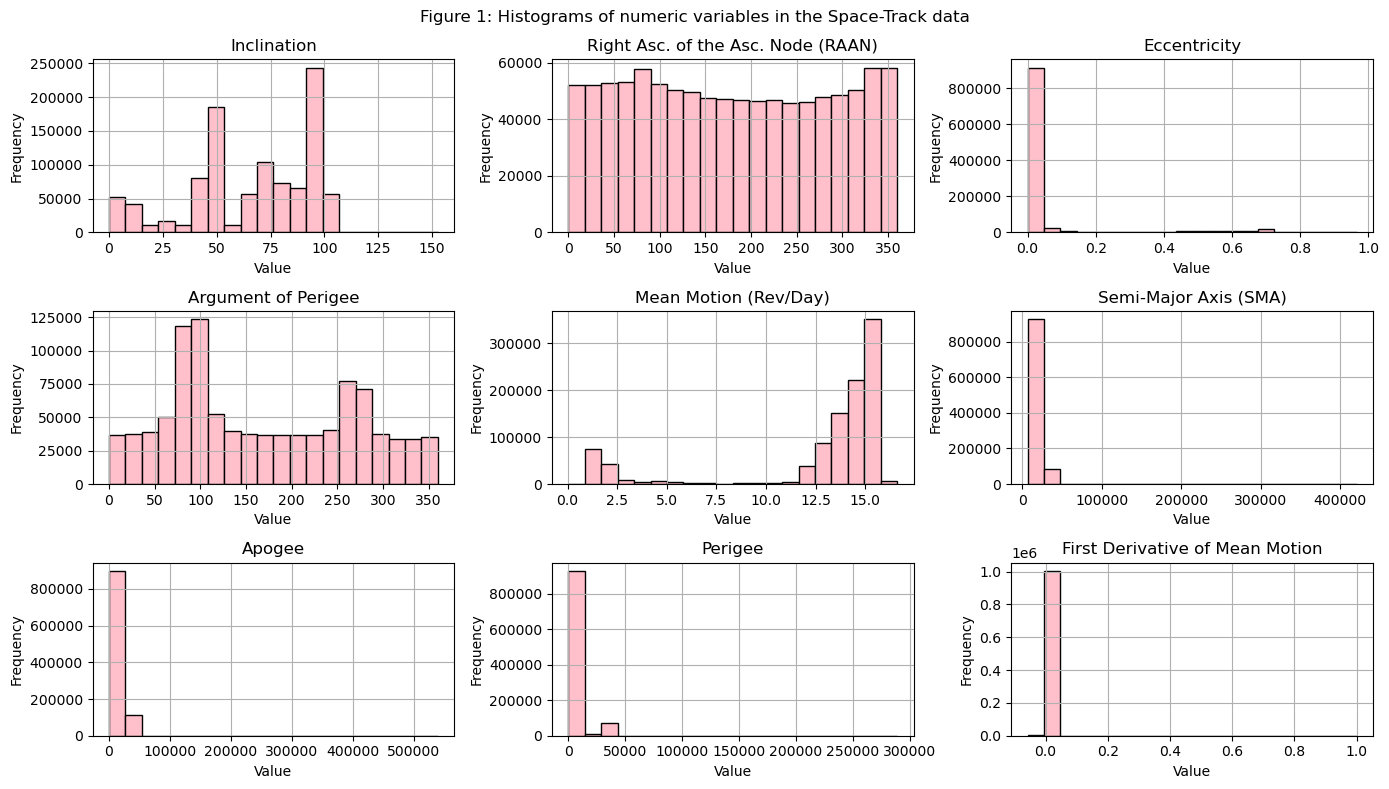

In [9]:
# plot histograms of numeric data
viz.plot_histograms(df, X_numerical2, column_names_map, "Figure 1: Histograms of numeric variables in the Space-Track data")


## Data Analysis 


### Correlation between Elements

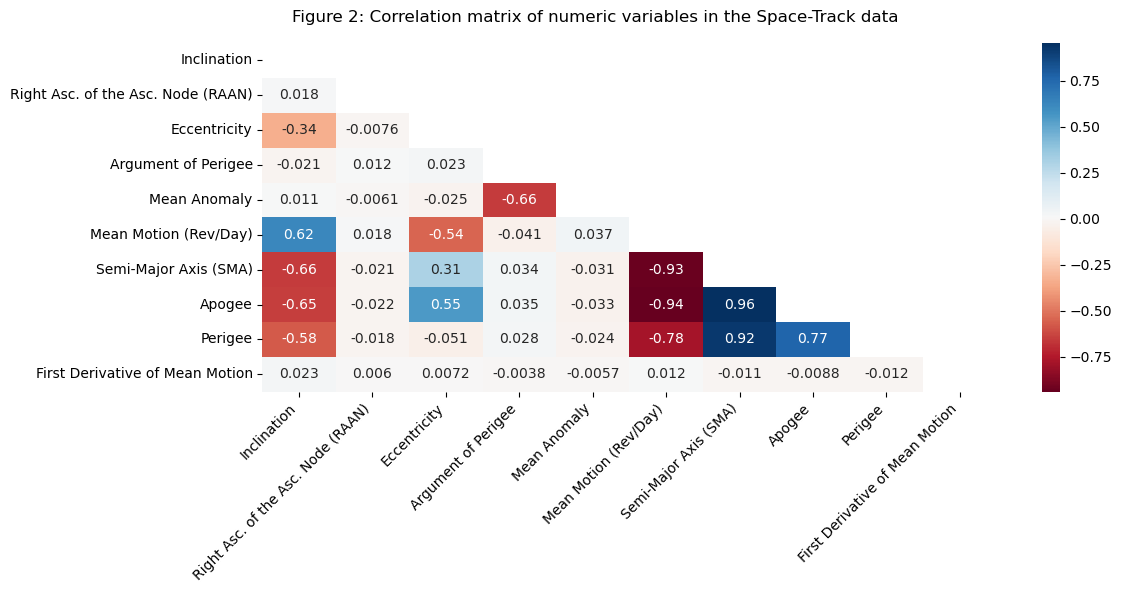

In [10]:
# plot a correlation matrix
viz.plot_corr_matrix(df_scaled, X_numerical, column_names_map, "Figure 2: Correlation matrix of numeric variables in the Space-Track data")

##### Patterns Discovered in Correlation Matrix

<table>
    <tbody>
        <tr>
            <th>Pattern A</th>
            <td>Circular orbits tend to have higher inclinations than elliptical orbits.</td>
        </tr>
        <tr>
            <th>Pattern B</th>
            <td>Lower Earth orbits are more likely to be more inclined than higher Earth orbits.</td>
        </tr>
        <tr>
            <th>Pattern C</th>
            <td>Lower Earth orbits tend to be more circular (lower eccentricity), while higher Earth orbits tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Trivial</th>
            <td>Trivial comparisons amount to saying "larger orbits will be larger" or "smaller orbits will be smaller."</td>
        </tr>
    </tbody>
</table>

<p>These patterns are consistent with our understanding of orbital dynamics, and they hold between object types.</p>


<table>
    <tbody>
        <tr>
            <th>Values</th>
            <th>Correlation</th>
            <th>Pattern</th>
            <th>Explanation</th>
        </tr>
        <tr>
            <th>Eccentricity vs. Inclination</th>
            <td>Slight Negative</td>
            <td>A</td>
            <td>Eccentricity describes the shape of an orbit: small values indicate a more circular orbit, while large values indicate a more elliptical one. A negative correlation suggests that orbits with higher inclination tend to be more circular in shape (lower eccentricity), while orbits with lower inclinations tend to be more elliptical (higher eccentricity).</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Inclination</th>
            <td>Positive</td>
            <td>B</td>
            <td>Mean motion refers to the number of times an object completes a rotation per day. Larger values indicate lower Earth orbits (which have more rotations per day). A positive correlation with inclination suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Semi-major Axis vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>The semi-major axis represents the longest semi-diameter of an orbit. Smaller values correspond to orbits closer to Earth. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Apogee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Apogee refers to the furthest point an object reaches from Earth in its orbit. A negative correlation with inclination indicates that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Perigee vs. Inclination</th>
            <td>Negative</td>
            <td>B</td>
            <td>Perigee is the closest point an object reaches to Earth in its orbit. A negative correlation with inclination again suggests that lower Earth orbits are more likely to be inclined, while higher Earth orbits are less likely to be inclined.</td>
        </tr>
        <tr>
            <th>Mean Motion vs. Eccentricity</th>
            <td>Negative</td>
            <td>C</td>
            <td>A negative correlation with mean motion indicates that more circular orbits (i.e., orbits with eccentricity closer to zero) will have a higher mean motion, meaning they will be closer to Earth.</td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Eccentricity</th>
            <td>Slight Positive</td>
            <td>C</td>
            <td>A positive correlation suggests higher Earth orbits tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Apogee vs. Eccentricity</th>
            <td>Positive</td>
            <td>C</td>
            <td>Orbits with higher apogees (furthest distance orbit goes from Earth) tend to be more eccentric (less circular).</td>
        </tr>
        <tr>
            <th>Mean Anomaly vs. Argument of Perigee</th>
            <td>Negative</td>
            <td>Likely Meaningless</td>
            <td>Mean anomaly is an angle that describes how much an orbit has been completed at a given time. Because of its connection to the epoch, we may want to drop it from our model. The argument of Perigee describes the orientation of the orbit in space. Mean anomaly is measured relative to the argument of perigee. Because mean anomaly is relative to when the orbit was epoched, we don't think that this correlation is meaningful. </td>
        </tr>
        <tr>
            <th>Semi-major axis vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large semi-major axis means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Mean Motion</th>
            <td>Very Strong Negative</td>
            <td>Trivial</td>
            <td>Large apogee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Mean Motion</th>
            <td>Strong Negative</td>
            <td>Trivial</td>
            <td>Large perigee means higher Earth orbit, and small mean motion means lower Earth orbit, so a negative correlation is a given.</td>
        </tr>
        <tr>
            <th>Apogee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Apogee is a subsection of the semi-major axis, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Semi-major axis</th>
            <td>Very Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
        <tr>
            <th>Perigee vs. Apogee</th>
            <td>Strong Positive</td>
            <td>Trivial</td>
            <td>Both of these measure an orbit's size or distance from Earth, so a positive correlation is a given.</td>
        </tr>
    </tbody>
</table>


##### Conclusions

1. Apogee, perigee, and semi-major axis encode simlilar/overlapping concepts. Some combination of these features might need to be dropped.

2. Mean anomaly is relative to epoch time and doesn't describe an orbit's shape. We should consider dropping this feature in our model.

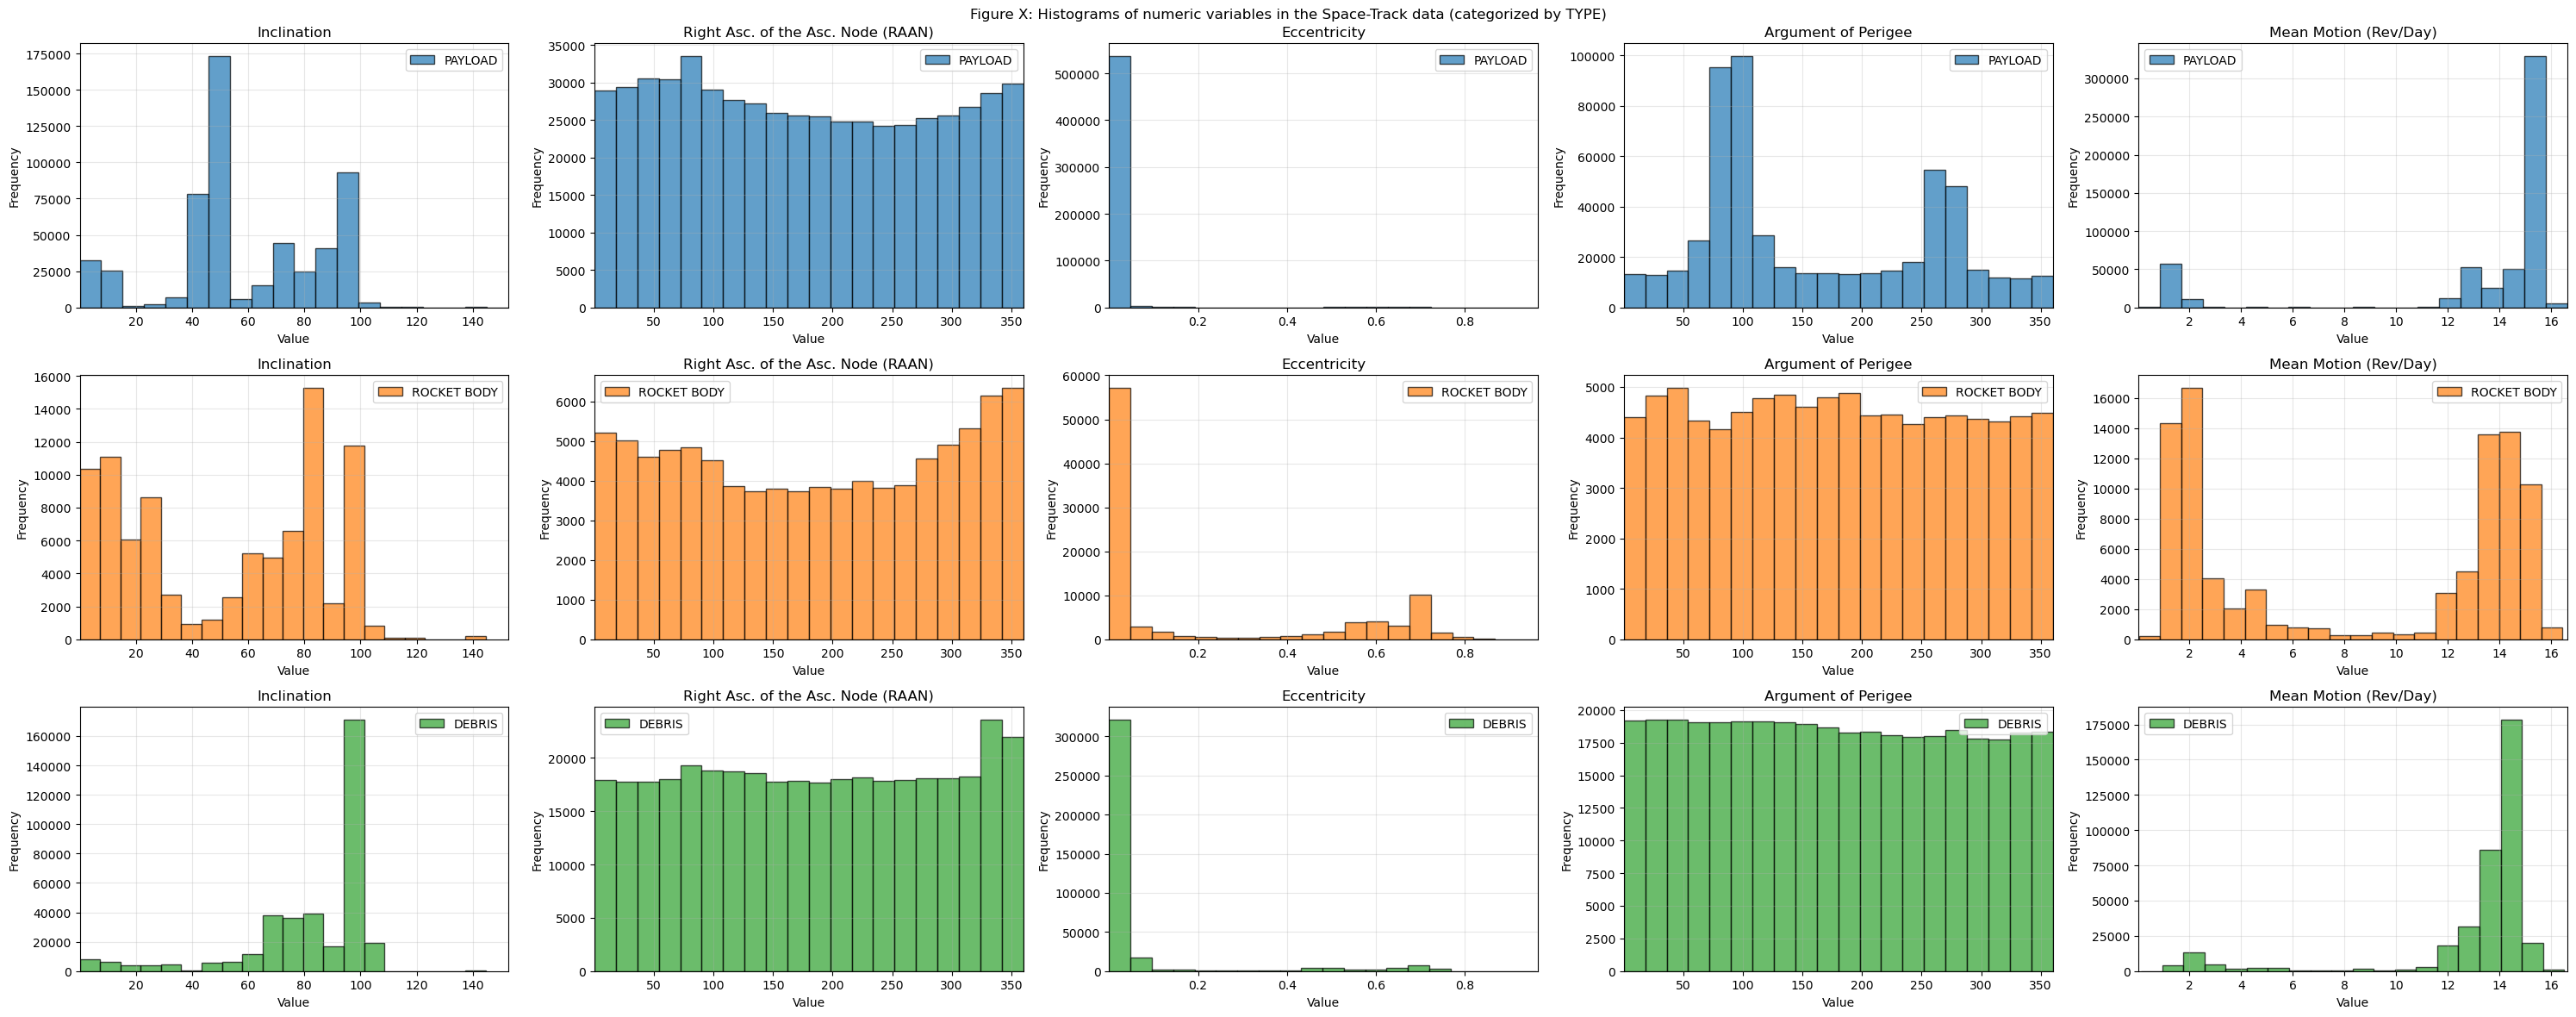

In [42]:
df = df
X_numerical3 = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION']
num_vars = X_numerical3
cat_var = "TYPE"
column_names_map = column_names_map
suptitle = "Figure X: Histograms of numeric variables in the Space-Track data (categorized by TYPE)"

cat_var_vals = df[cat_var].unique()
fig, axes = plt.subplots(ncols=len(num_vars), nrows=len(cat_var_vals), figsize=(6*len(num_vars), 4*len(cat_var_vals)))
for i, num_var in enumerate(num_vars):
    var_min, var_max = df[num_var].min(), df[num_var].max()
    for j, cat in enumerate(cat_var_vals):
        filter_df = df[df[cat_var]==cat]
        axes[j][i].hist(filter_df[num_var], bins=20, color=f"C{j}", alpha=0.7, edgecolor="black", label=cat)
        axes[j][i].set_title(column_names_map[num_var])
        axes[j][i].set_xlabel('Value')
        axes[j][i].set_ylabel('Frequency')
        axes[j][i].set_xlim(var_min, var_max)
        axes[j][i].grid(alpha=0.3)
        axes[j][i].legend()
plt.suptitle(suptitle)
plt.tight_layout()
plt.show()

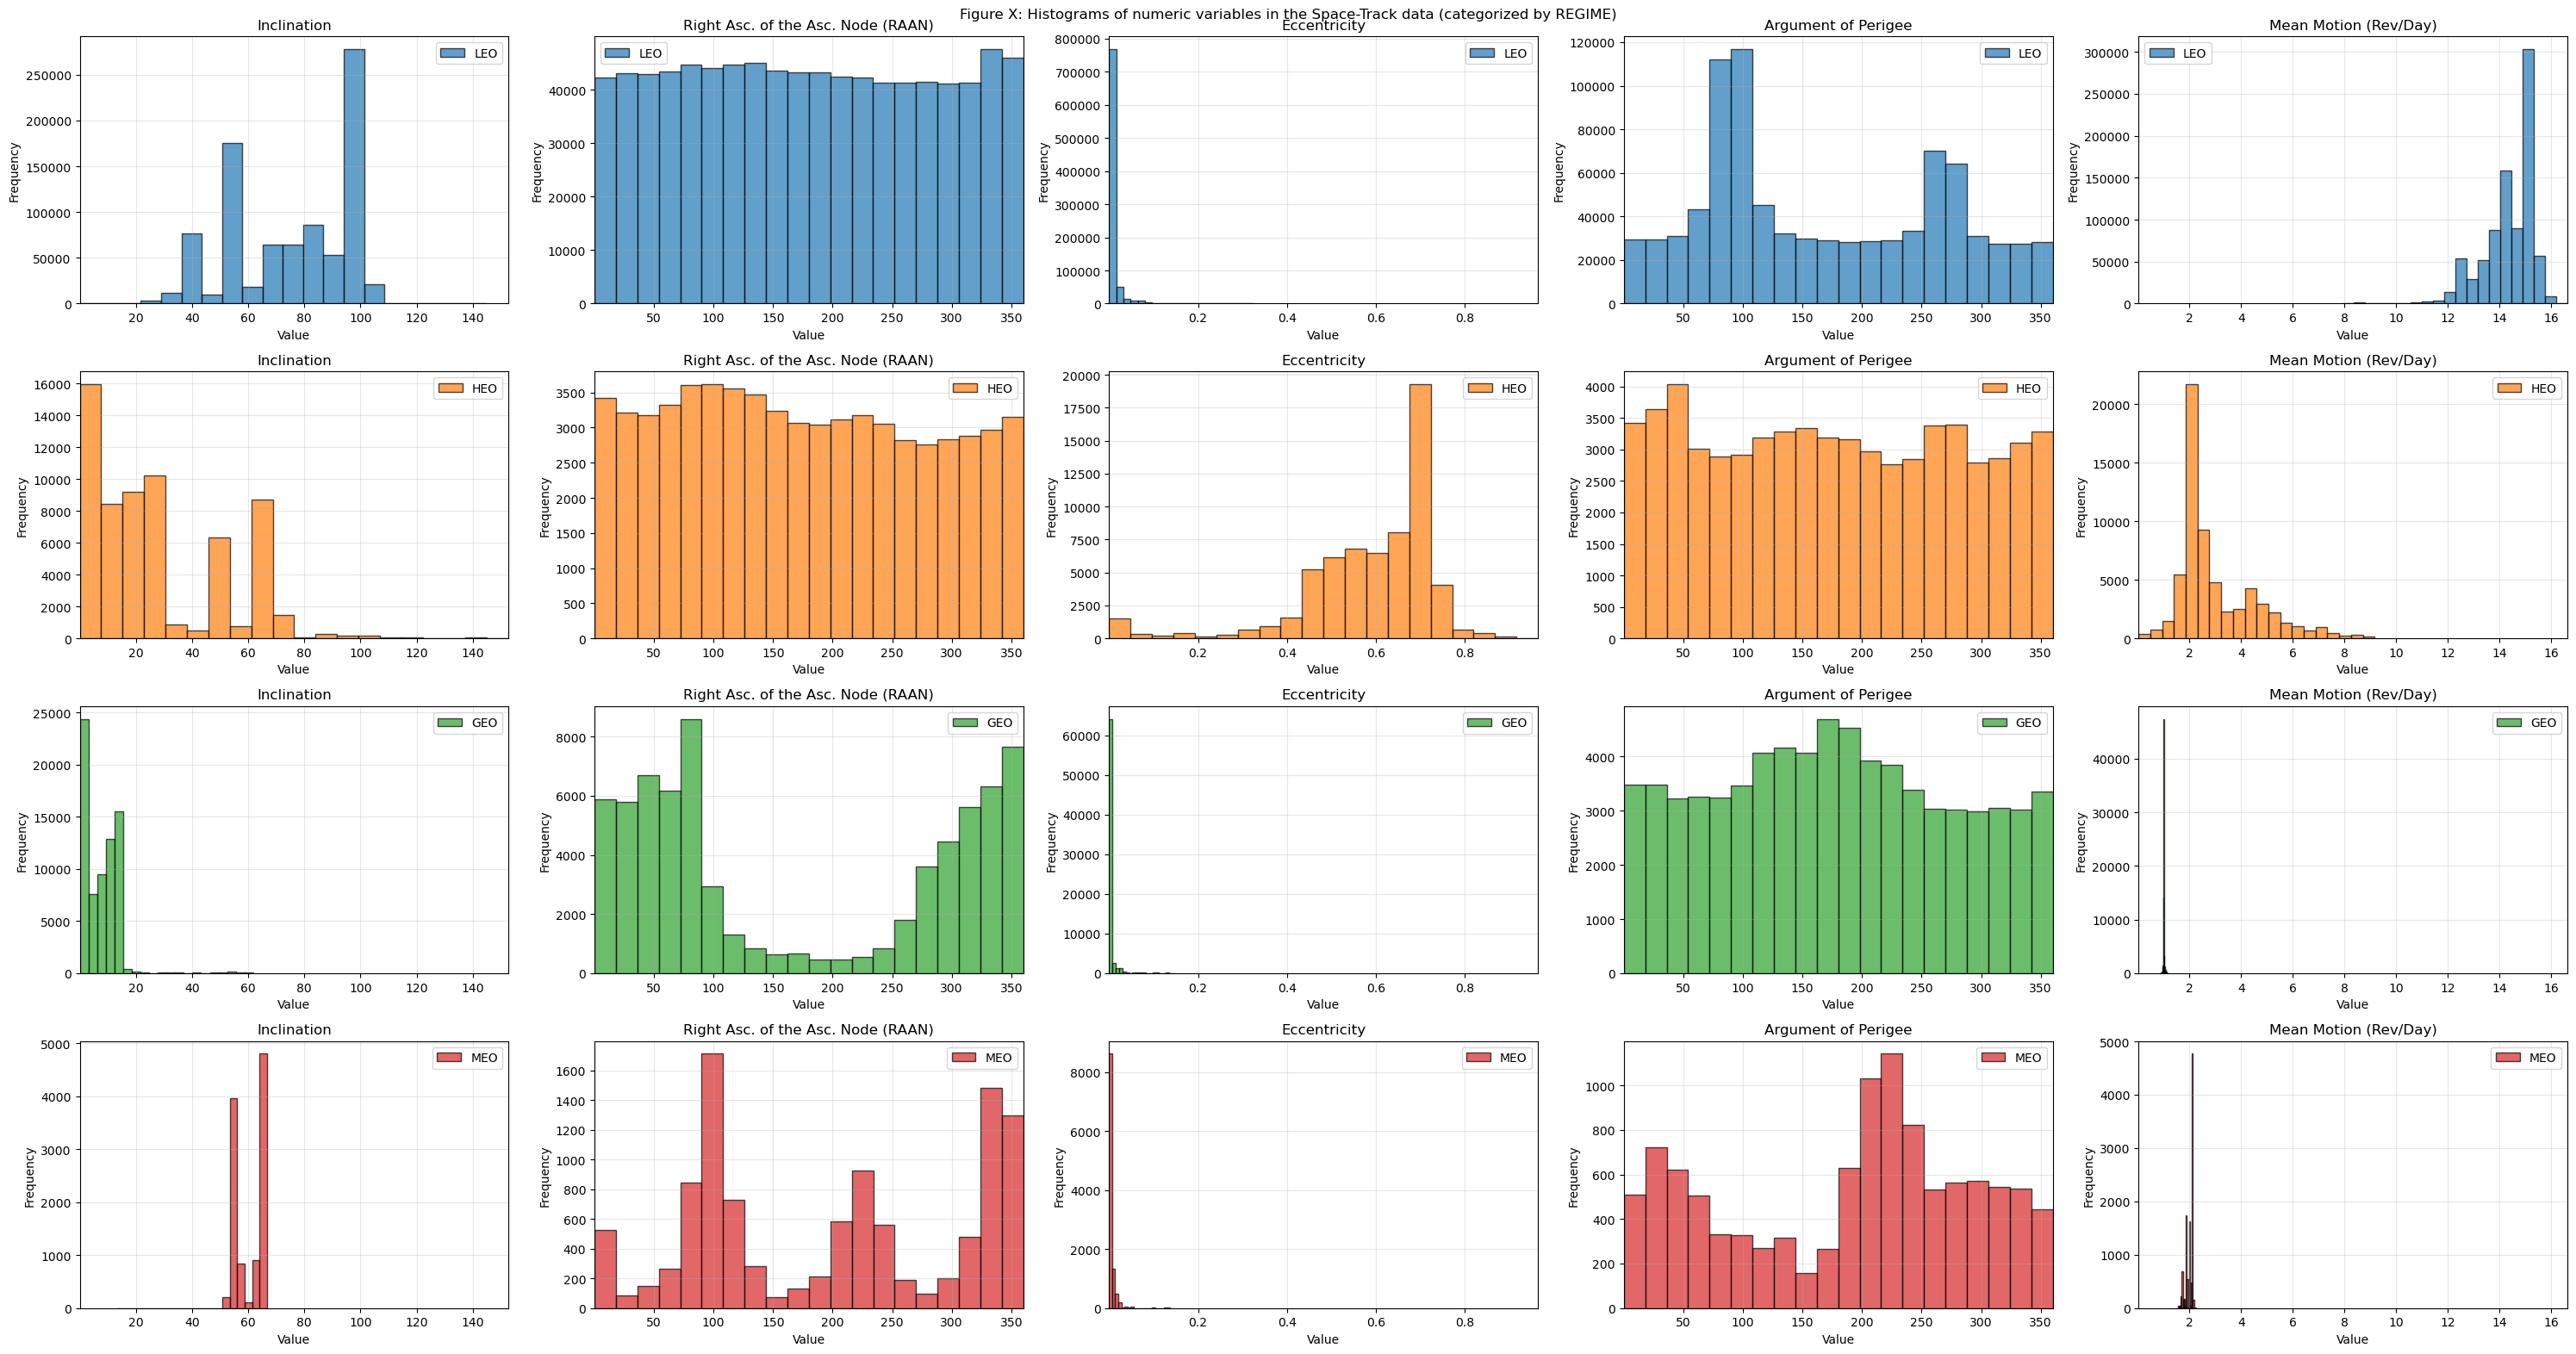

In [43]:
df = df
X_numerical3 = ['INCL', 'RAAN', 'ECC', 'ARG_PER', 'MEAN_MOTION']
num_vars = X_numerical3
cat_var = "REGIME"
column_names_map = column_names_map
suptitle = "Figure X: Histograms of numeric variables in the Space-Track data (categorized by REGIME)"

cat_var_vals = df[cat_var].unique()
fig, axes = plt.subplots(ncols=len(num_vars), nrows=len(cat_var_vals), figsize=(6*len(num_vars), 4*len(cat_var_vals)))
for i, num_var in enumerate(num_vars):
    var_min, var_max = df[num_var].min(), df[num_var].max()
    for j, cat in enumerate(cat_var_vals):
        filter_df = df[df[cat_var]==cat]
        axes[j][i].hist(filter_df[num_var], bins=20, color=f"C{j}", alpha=0.7, edgecolor="black", label=cat)
        axes[j][i].set_title(column_names_map[num_var])
        axes[j][i].set_xlabel('Value')
        axes[j][i].set_ylabel('Frequency')
        axes[j][i].set_xlim(var_min, var_max)
        axes[j][i].grid(alpha=0.3)
        axes[j][i].legend()
plt.suptitle(suptitle)
plt.tight_layout()
plt.show()

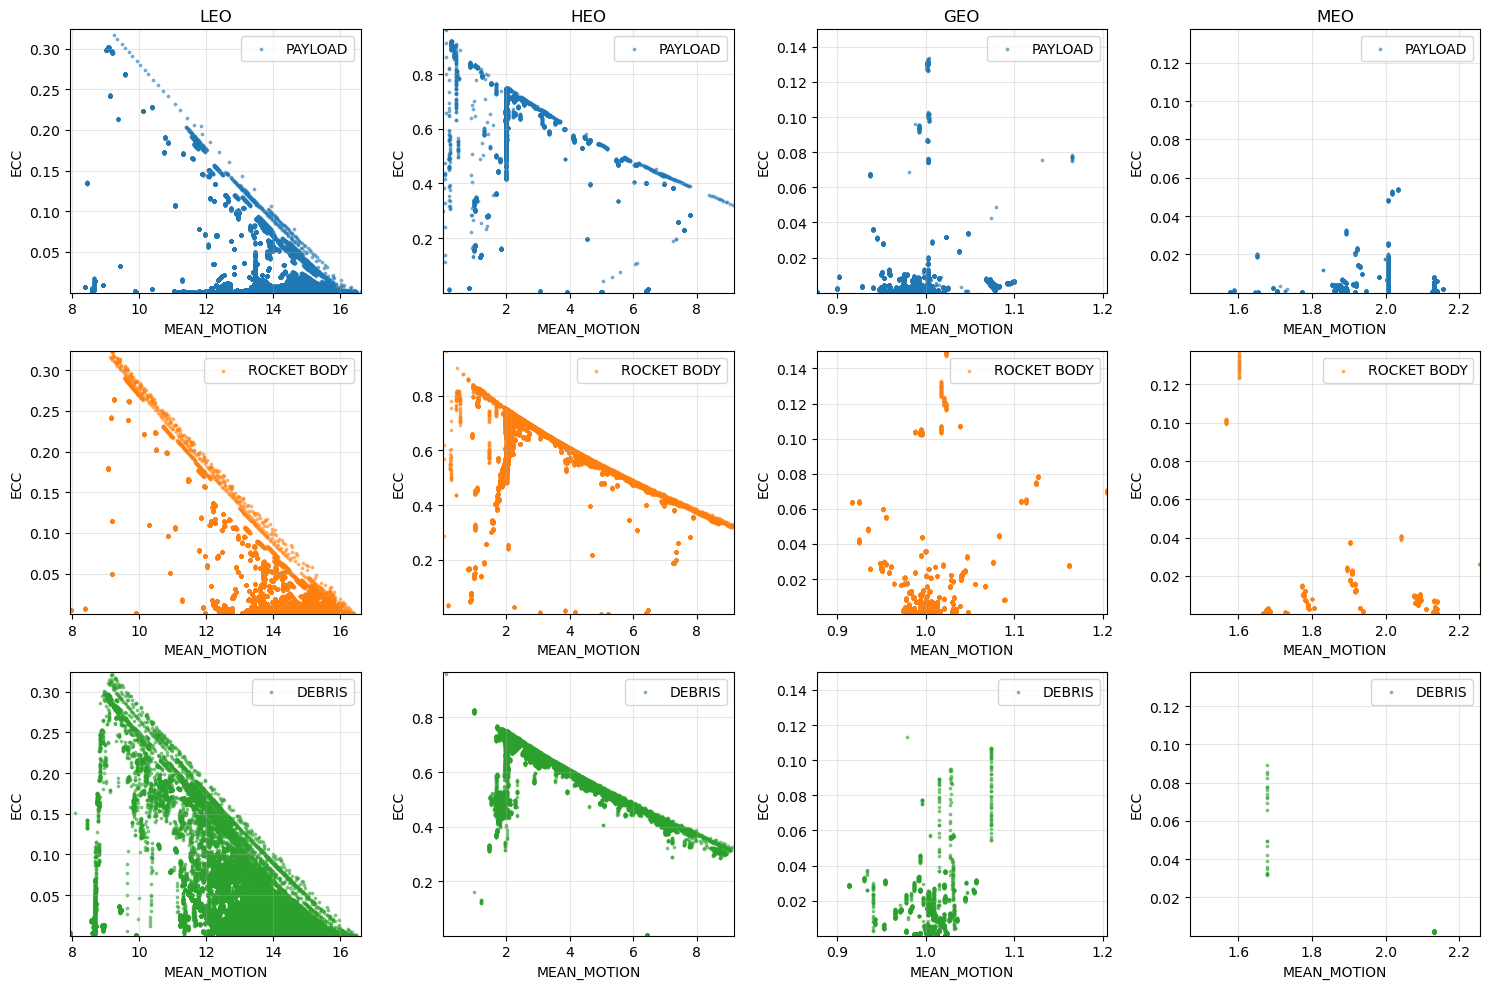

In [38]:
cat_var1 = "REGIME"
cat_var2 = "TYPE"
num_var1 = "MEAN_MOTION"
num_var2 = "ECC"

cat_var1_vals, cat_var2_vals = df[cat_var1].unique(), df[cat_var2].unique()
fig, axes = plt.subplots(nrows=len(cat_var2_vals), ncols=len(cat_var1_vals), figsize=(15,10))
for i, cat1 in enumerate(cat_var1_vals):
    axes[0][i].set_title(cat1)
    sub_df = df[df[cat_var1]==cat1]
    var1_min, var1_max = sub_df[num_var1].min(), sub_df[num_var1].max()
    var2_min, var2_max = sub_df[num_var2].min(), sub_df[num_var2].max()
    for j, cat2 in enumerate(cat_var2_vals):
        filter_df = df[(df[cat_var1]==cat1)&(df[cat_var2]==cat2)]
        # Maybe instead of scatterplot use kde?
        axes[j][i].scatter(filter_df[num_var1], filter_df[num_var2], c=f"C{j}", s=3, alpha=0.5, label=cat2)
        # sns.kdeplot(x=filter_df[num_var1], y=filter_df[num_var2], color=f"C{j}", ax=axes[j][i])
        axes[j][i].legend(loc="upper right")
        axes[j][i].grid(alpha=0.3)
        axes[j][i].set_xlim(var1_min, var1_max)
        axes[j][i].set_ylim(var2_min, var2_max)
        axes[j][i].set_xlabel(num_var1)
        axes[j][i].set_ylabel(num_var2)

plt.tight_layout()

### Principal Component Analysis (PCA)

In [12]:
# PCA without the specified columns below
df_to_use = df_scaled
df_to_use = df_to_use.drop(columns=['TYPE','NUMBER', 'NAME', 'IS_CURRENT', 'REGIME', 'EPOCH', 'COUNTRY', 'LINE1', 'LINE2', 'MEAN_ANOM', 'RCS'])
pca = PCA(n_components=len(df_to_use.columns))  
pca_result = pca.fit_transform(df_to_use)

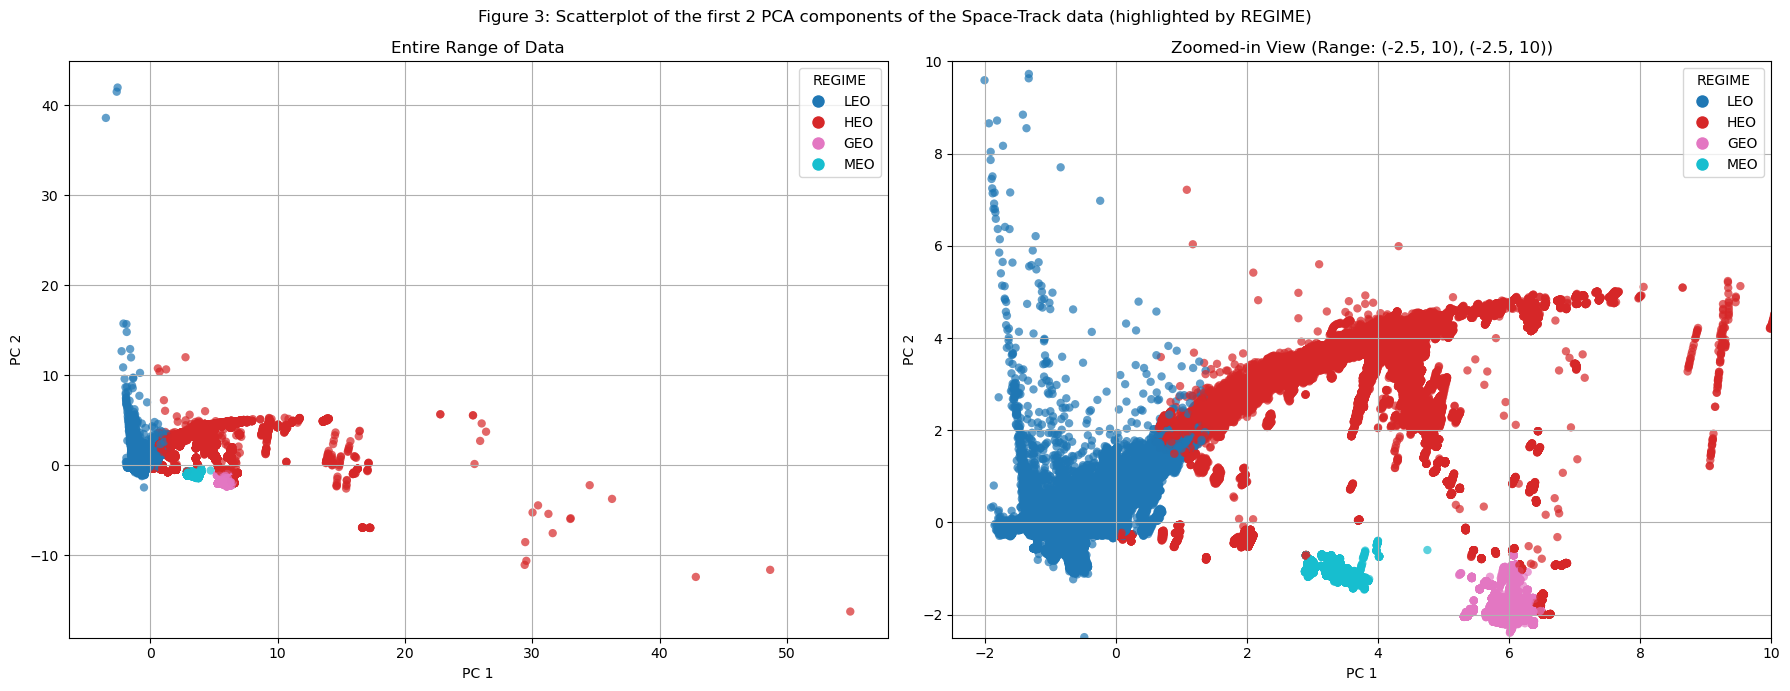

In [13]:
# visualize PCA results by regime
viz.pca_pc1_pc2_pair(pca_result, df_scaled["REGIME"], "REGIME", "Figure 3: Scatterplot of the first 2 PCA components of the Space-Track data (highlighted by REGIME)", x_range=(-2.5, 10), y_range=(-2.5, 10))

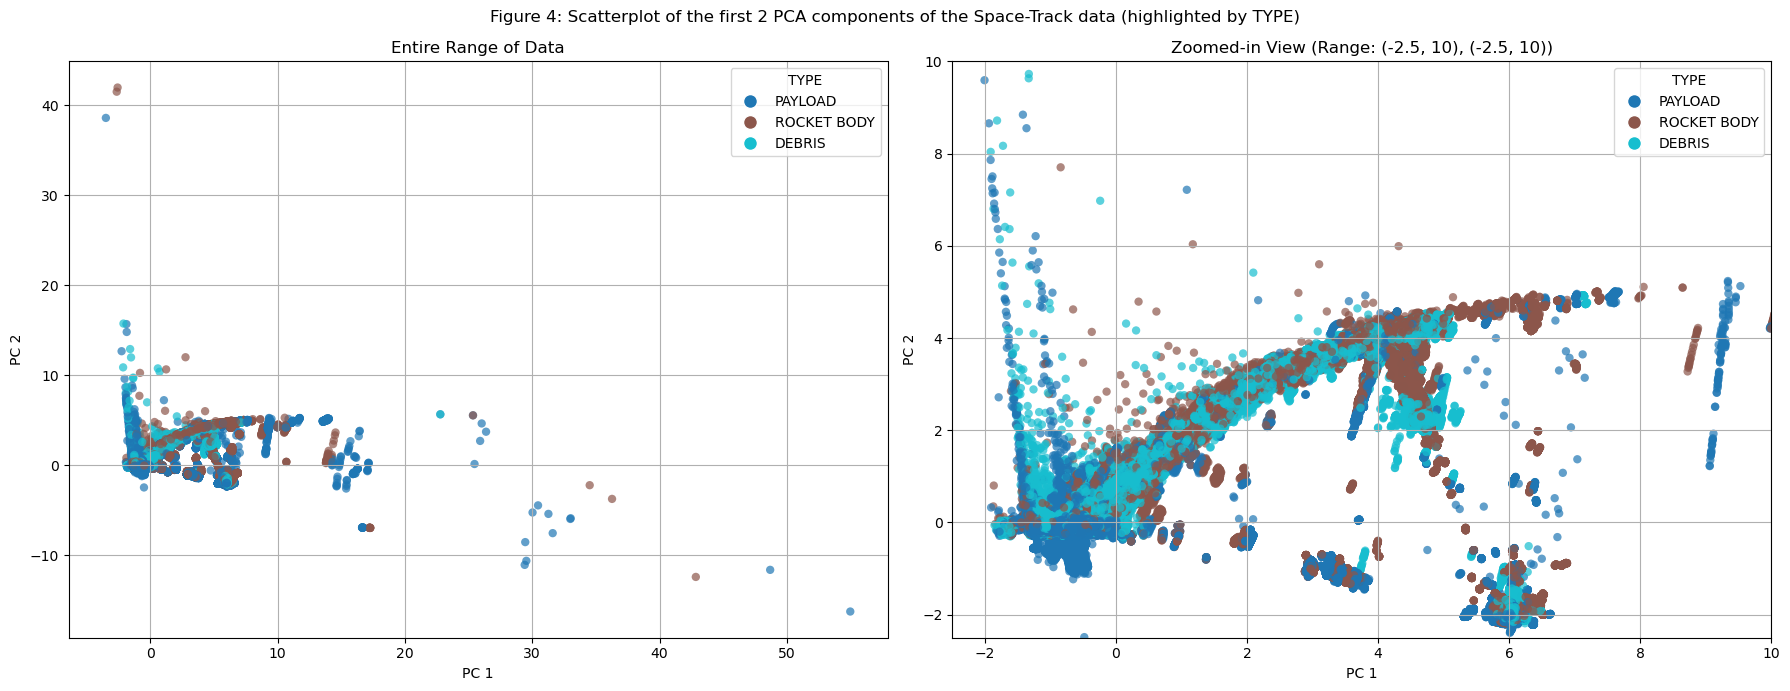

In [14]:
# visualize PCA results by type
viz.pca_pc1_pc2_pair(pca_result, df_scaled["TYPE"], "TYPE", "Figure 4: Scatterplot of the first 2 PCA components of the Space-Track data (highlighted by TYPE)", x_range=(-2.5, 10), y_range=(-2.5, 10))

## Summary of findings


Instructions: Summarize your findings in a clear and concise manner. This can be achieved through the use of visualizations and captions that highlight the most important insights gained through the analysis.

## (Revised) Project Question


Instructions: Based on the insights gained through EDA, you should develop a clear project/research question that will guide your analysis. This question should be well-defined, specific to the problem at hand, and an improvement from the initial project proposal.